# Diwali Sales — Insights & Machine Learning

**Goal:** use `matplotlib` / `seaborn` to surface the customer insights, then train ML **regression** models that predict **how much a customer is likely to spend (`Amount`, in ₹)** during Diwali from their demographic information, occupation, location, number of orders and product category.

**Models compared:** Ridge, Random Forest, Gradient Boosting, **XGBoost, LightGBM** (± log-transformed target) — selected by 5-fold CV, top-2 tuned with `RandomizedSearchCV`.

**Features:** `Gender`, `Age`, `Age Group`, `Marital_Status`, `State`, `Zone`, `Occupation`, `Orders`, `Product_Category`
**Target:** `Amount` — purchase spend in ₹


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import joblib

from sklearn.model_selection import train_test_split, cross_val_score, KFold, RandomizedSearchCV
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error,
)

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

sns.set_theme(style='whitegrid')
RANDOM_STATE = 42


## 1. Load & Clean

In [3]:
df = pd.read_csv('Diwali Sales Data.csv', encoding='unicode_escape')

# drop empty columns and rows with missing Amount
df.drop(['Status', 'unnamed1'], axis=1, inplace=True)
df.dropna(inplace=True)
df['Amount'] = df['Amount'].astype('int')

# highlight categories used in the EDA charts
TARGET_CATS = ['Food', 'Clothing & Apparel', 'Electronics & Gadgets']

df.shape, df['Amount'].describe().round(0).to_dict()


((11239, 13),
 {'count': 11239.0,
  'mean': 9454.0,
  'std': 5222.0,
  'min': 188.0,
  '25%': 5443.0,
  '50%': 8109.0,
  '75%': 12675.0,
  'max': 23952.0})

## 2. Exploratory Data Analysis — insights behind the conclusion

### 2.1 Gender — who buys & how much they spend

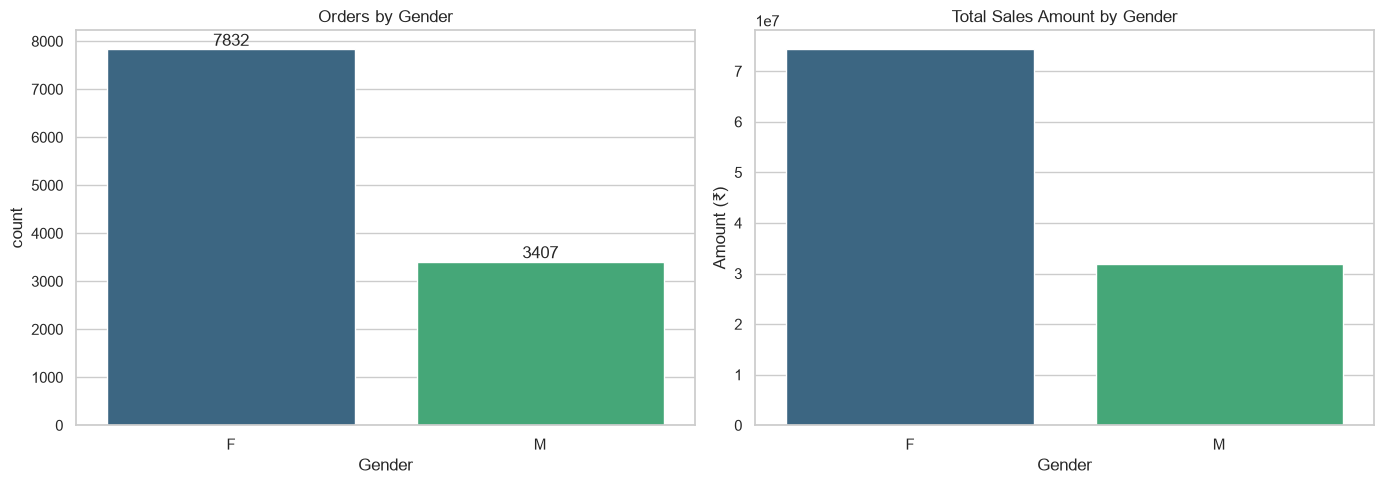

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = sns.countplot(data=df, x='Gender', hue='Gender', palette='viridis', legend=False, ax=axes[0])
for c in ax.containers:
    ax.bar_label(c)
axes[0].set_title('Orders by Gender')

sales_gen = df.groupby('Gender', as_index=False)['Amount'].sum()
sns.barplot(data=sales_gen, x='Gender', y='Amount', hue='Gender', palette='viridis', legend=False, ax=axes[1])
axes[1].set_title('Total Sales Amount by Gender')
axes[1].set_ylabel('Amount (₹)')

plt.tight_layout()

*Insight: female buyers dominate both order count and total spend.*

### 2.2 Age Group × Gender

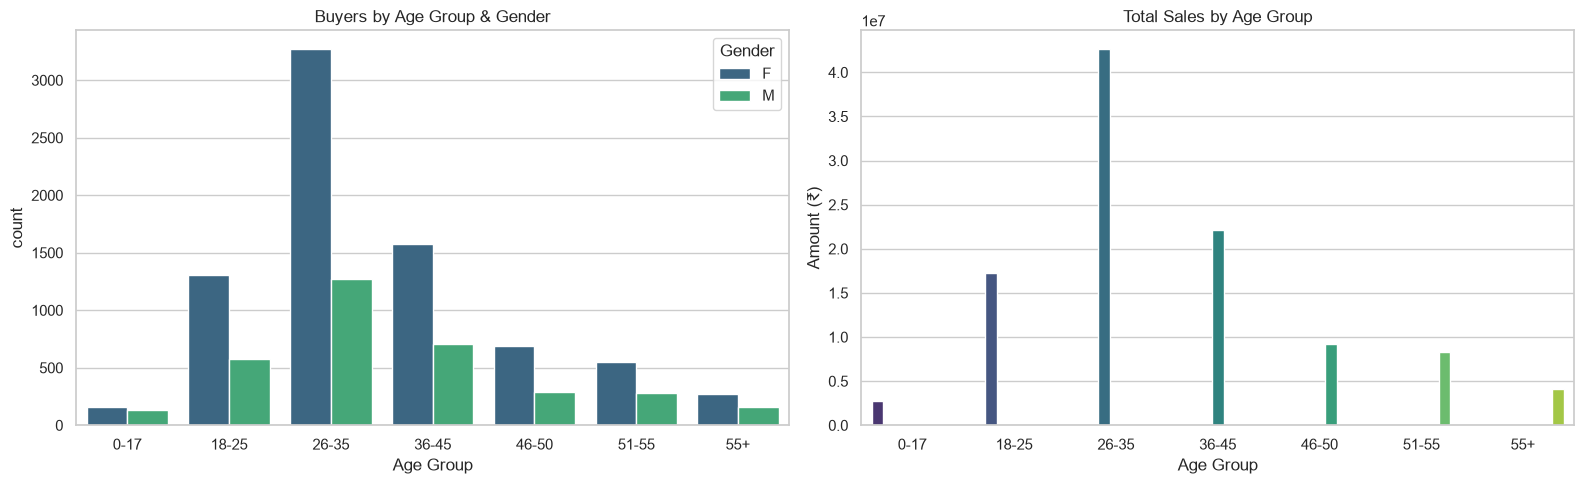

In [5]:
age_order = ['0-17', '18-25', '26-35', '36-45', '46-50', '51-55', '55+']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.countplot(data=df, x='Age Group', hue='Gender', order=age_order, palette='viridis', ax=axes[0])
axes[0].set_title('Buyers by Age Group & Gender')

sales_age = df.groupby('Age Group', as_index=False)['Amount'].sum()
sales_age['Age Group'] = pd.Categorical(sales_age['Age Group'], categories=age_order, ordered=True)
sales_age = sales_age.sort_values('Age Group')
sns.barplot(data=sales_age, x='Age Group', y='Amount', hue='Age Group', palette='viridis', legend=False, ax=axes[1])
axes[1].set_title('Total Sales by Age Group')
axes[1].set_ylabel('Amount (₹)')

plt.tight_layout()

*Insight: the 26-35 age group — especially women — places the most orders and spends the most.*

### 2.3 State — where the orders come from

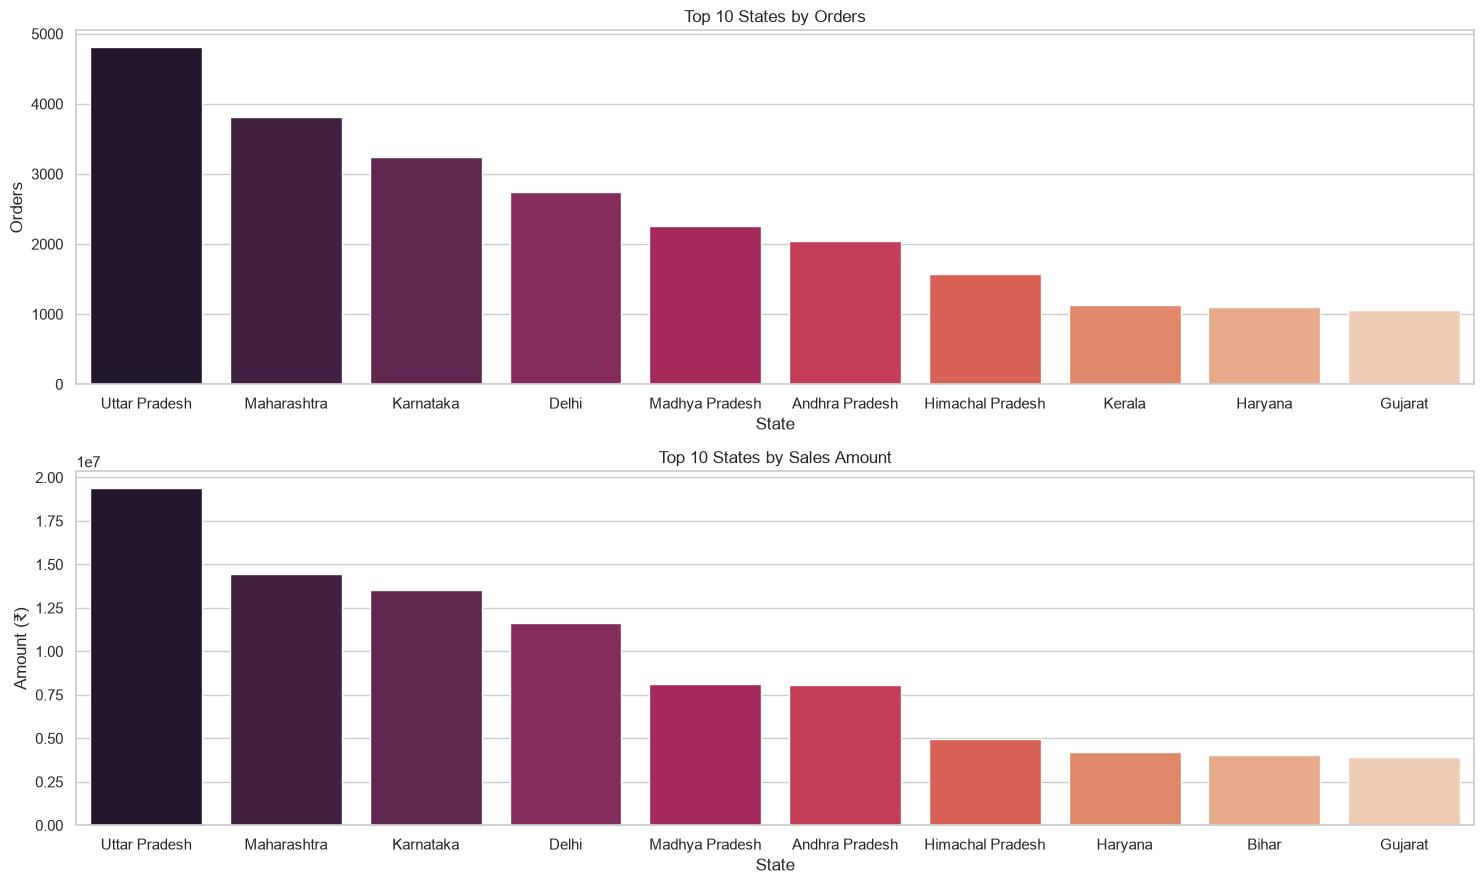

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(15, 9))

sales_state_o = (df.groupby('State', as_index=False)['Orders'].sum()
                 .sort_values('Orders', ascending=False).head(10))
sns.barplot(data=sales_state_o, x='State', y='Orders', hue='State', palette='rocket', legend=False, ax=axes[0])
axes[0].set_title('Top 10 States by Orders')

sales_state_a = (df.groupby('State', as_index=False)['Amount'].sum()
                 .sort_values('Amount', ascending=False).head(10))
sns.barplot(data=sales_state_a, x='State', y='Amount', hue='State', palette='rocket', legend=False, ax=axes[1])
axes[1].set_title('Top 10 States by Sales Amount')
axes[1].set_ylabel('Amount (₹)')

plt.tight_layout()

*Insight: Uttar Pradesh, Maharashtra and Karnataka lead in both orders and revenue.*

### 2.4 Marital Status × Gender

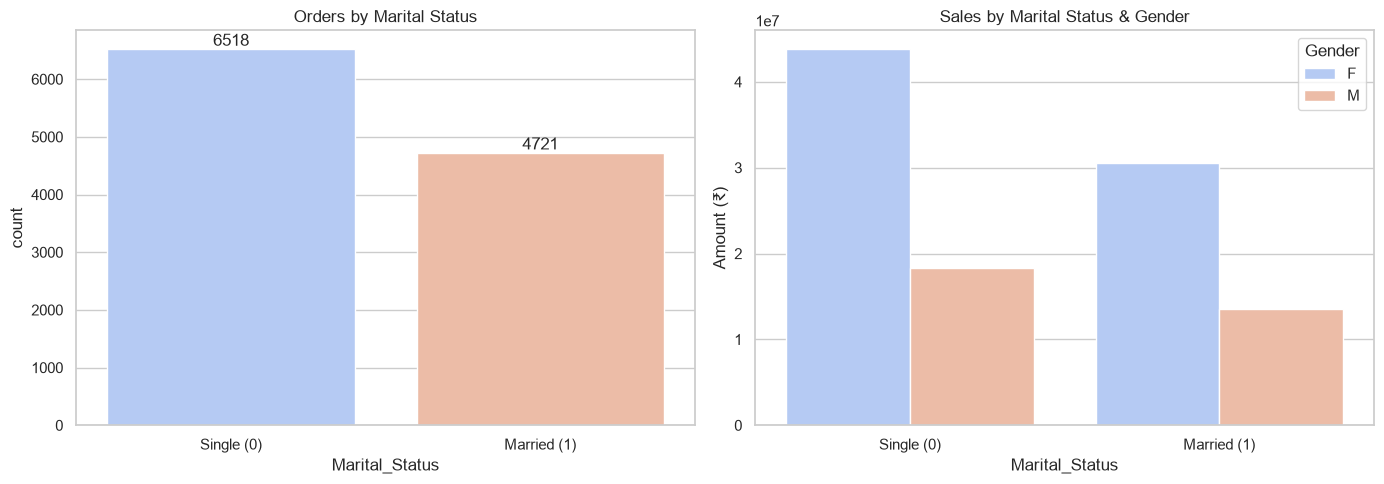

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = sns.countplot(data=df, x='Marital_Status', hue='Marital_Status', palette='coolwarm',
                   legend=False, ax=axes[0])
for c in ax.containers:
    ax.bar_label(c)
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Single (0)', 'Married (1)'])
axes[0].set_title('Orders by Marital Status')

sales_mar = df.groupby(['Marital_Status', 'Gender'], as_index=False)['Amount'].sum()
sns.barplot(data=sales_mar, x='Marital_Status', y='Amount', hue='Gender', palette='coolwarm', ax=axes[1])
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Single (0)', 'Married (1)'])
axes[1].set_title('Sales by Marital Status & Gender')
axes[1].set_ylabel('Amount (₹)')

plt.tight_layout()

*Insight: married buyers — particularly married women — have the highest purchasing power.*

### 2.5 Occupation (IT / Healthcare / Aviation highlighted)

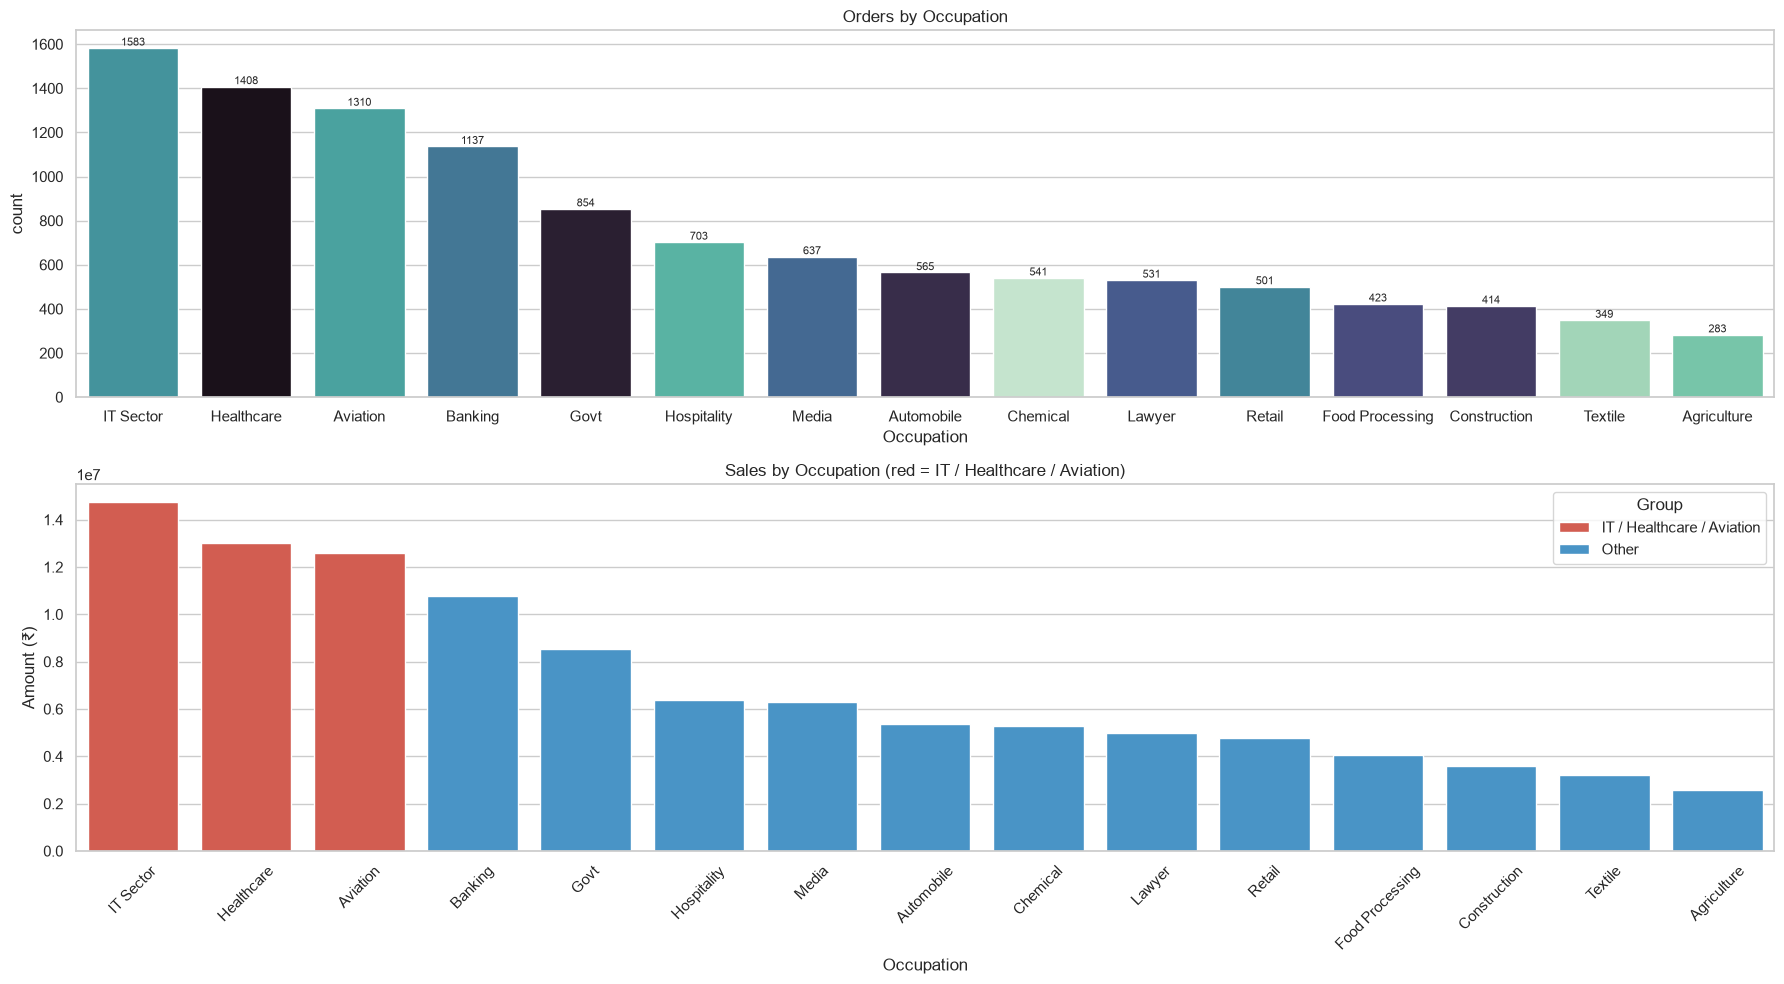

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(18, 10))

occ_order = df['Occupation'].value_counts().index
ax = sns.countplot(data=df, x='Occupation', hue='Occupation', order=occ_order,
                   palette='mako', legend=False, ax=axes[0])
for c in ax.containers:
    ax.bar_label(c, fontsize=8)
axes[0].set_title('Orders by Occupation')

TOP_OCC = ['IT Sector', 'Healthcare', 'Aviation']
sales_occ = df.groupby('Occupation', as_index=False)['Amount'].sum().sort_values('Amount', ascending=False)
sales_occ['Group'] = np.where(sales_occ['Occupation'].isin(TOP_OCC), 'IT / Healthcare / Aviation', 'Other')
sns.barplot(data=sales_occ, x='Occupation', y='Amount', hue='Group',
            palette={'IT / Healthcare / Aviation': '#e74c3c', 'Other': '#3498db'}, ax=axes[1])
axes[1].set_title('Sales by Occupation (red = IT / Healthcare / Aviation)')
axes[1].set_ylabel('Amount (₹)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()

*Insight: IT, Healthcare and Aviation occupations spend the most.*

### 2.6 Product Category (Food / Clothing / Electronics highlighted)

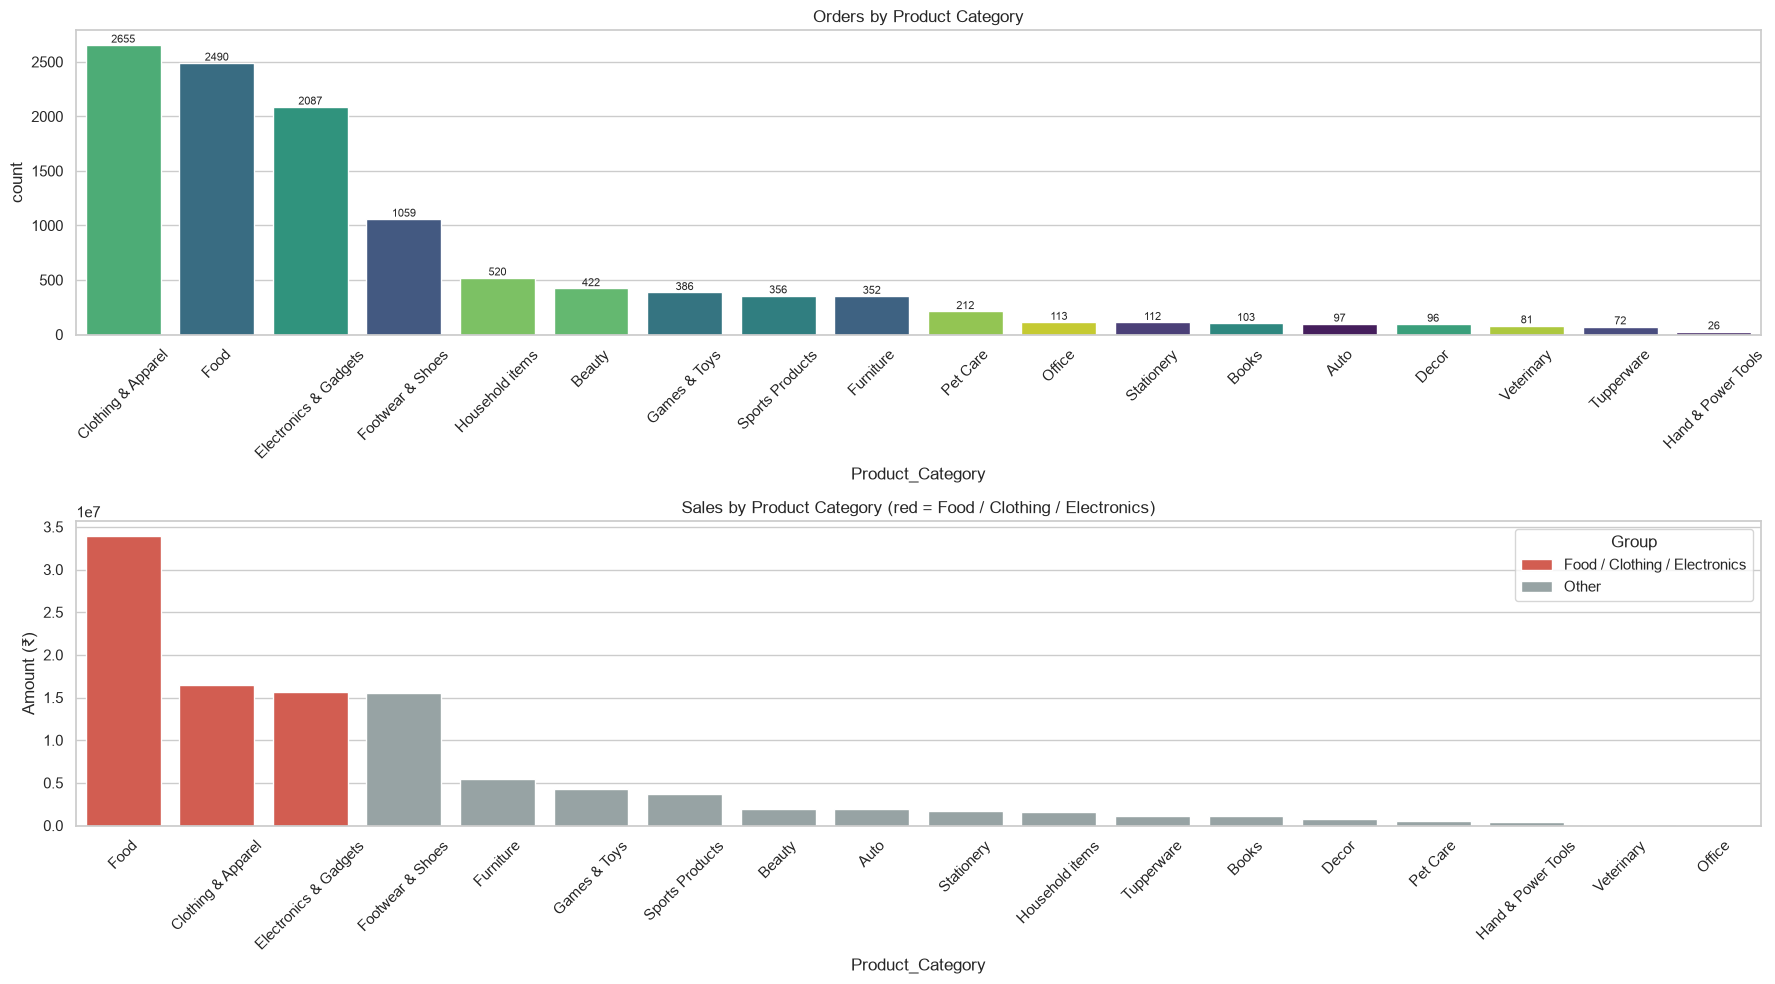

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(18, 10))

cat_order = df['Product_Category'].value_counts().index
ax = sns.countplot(data=df, x='Product_Category', hue='Product_Category', order=cat_order,
                   palette='viridis', legend=False, ax=axes[0])
for c in ax.containers:
    ax.bar_label(c, fontsize=8)
axes[0].set_title('Orders by Product Category')
axes[0].tick_params(axis='x', rotation=45)

sales_cat = df.groupby('Product_Category', as_index=False)['Amount'].sum().sort_values('Amount', ascending=False)
sales_cat['Group'] = np.where(sales_cat['Product_Category'].isin(TARGET_CATS), 'Food / Clothing / Electronics', 'Other')
sns.barplot(data=sales_cat, x='Product_Category', y='Amount', hue='Group',
            palette={'Food / Clothing / Electronics': '#e74c3c', 'Other': '#95a5a6'}, ax=axes[1])
axes[1].set_title('Sales by Product Category (red = Food / Clothing / Electronics)')
axes[1].set_ylabel('Amount (₹)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()

*Insight: Food, Clothing & Apparel and Electronics & Gadgets dominate orders and revenue.*

### 2.7 Cross heatmaps — who buys what

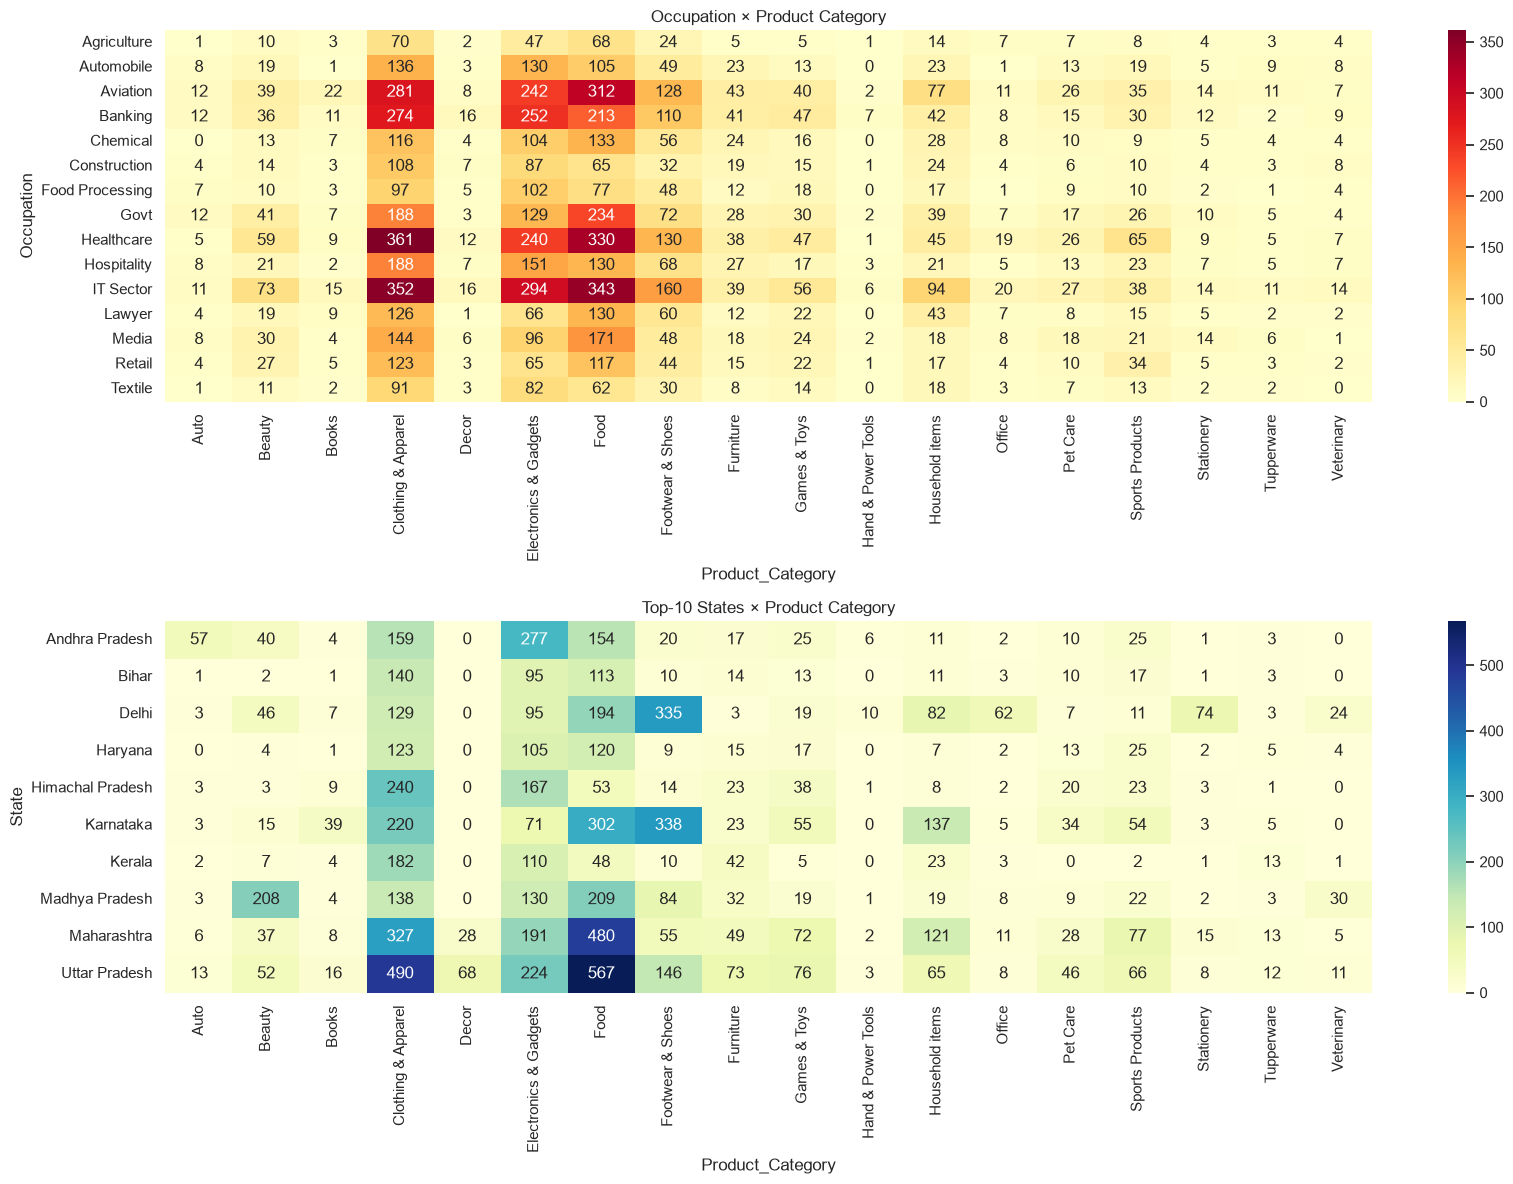

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(17, 12))

ct_occ = pd.crosstab(df['Occupation'], df['Product_Category'])
sns.heatmap(ct_occ, annot=True, fmt='d', cmap='YlOrRd', ax=axes[0])
axes[0].set_title('Occupation × Product Category')

top_states = df['State'].value_counts().head(10).index
sub = df[df['State'].isin(top_states)]
ct_state = pd.crosstab(sub['State'], sub['Product_Category'])
sns.heatmap(ct_state, annot=True, fmt='d', cmap='YlGnBu', ax=axes[1])
axes[1].set_title('Top-10 States × Product Category')

plt.tight_layout()

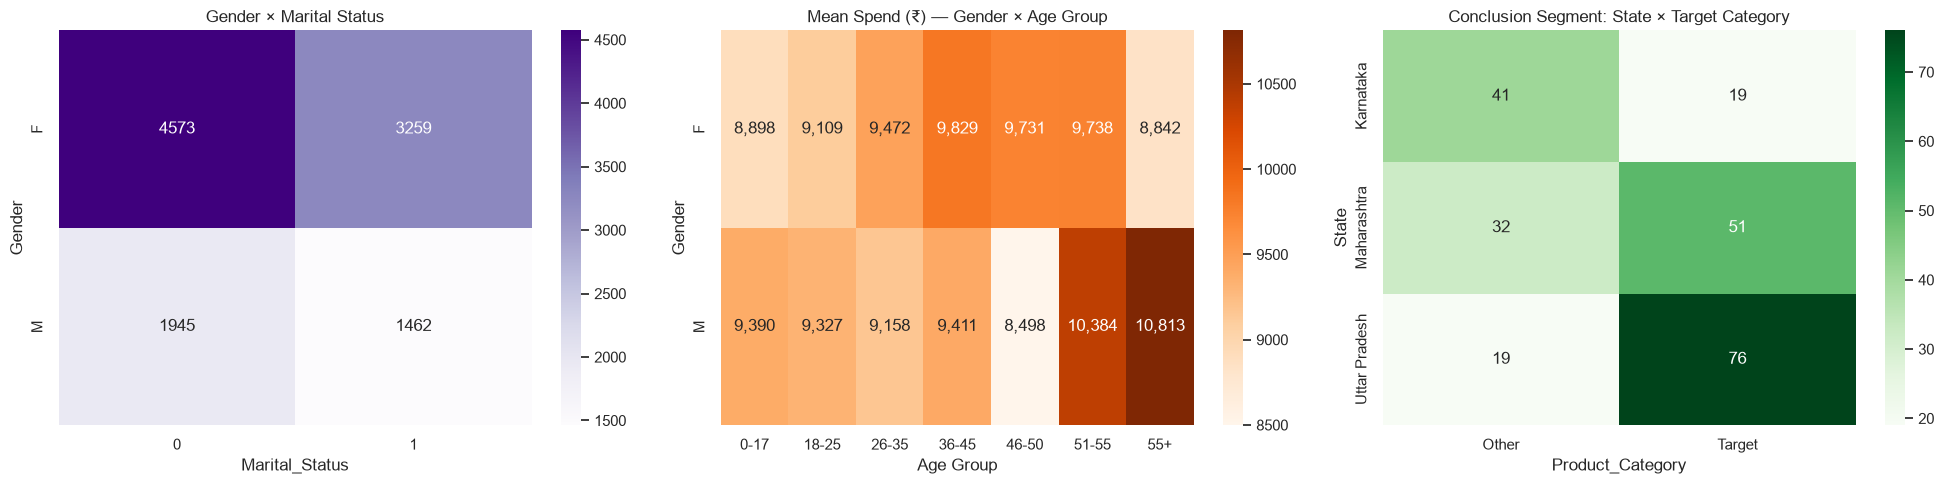

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

ct_gm = pd.crosstab(df['Gender'], df['Marital_Status'])
sns.heatmap(ct_gm, annot=True, fmt='d', cmap='Purples', ax=axes[0])
axes[0].set_title('Gender × Marital Status')

spend_ga = (df.pivot_table(index='Gender', columns='Age Group',
                           values='Amount', aggfunc='mean')
             .reindex(columns=age_order))
sns.heatmap(spend_ga, annot=True, fmt=',.0f', cmap='Oranges', ax=axes[1])
axes[1].set_title('Mean Spend (₹) — Gender × Age Group')

seg = df[(df['Gender'] == 'F') & (df['Marital_Status'] == 1) &
         (df['Age Group'] == '26-35') &
         (df['State'].isin(['Uttar Pradesh', 'Maharashtra', 'Karnataka'])) &
         (df['Occupation'].isin(TOP_OCC))]
ct_seg = pd.crosstab(seg['State'], seg['Product_Category'].isin(TARGET_CATS)
                     .map({True: 'Target', False: 'Other'}))
sns.heatmap(ct_seg, annot=True, fmt='d', cmap='Greens', ax=axes[2])
axes[2].set_title('Conclusion Segment: State × Target Category')

plt.tight_layout()


### 2.8 Target — purchase spend (`Amount`)

count    11239.0
mean      9454.0
std       5222.0
min        188.0
25%       5443.0
50%       8109.0
75%      12675.0
max      23952.0
Name: Amount, dtype: float64

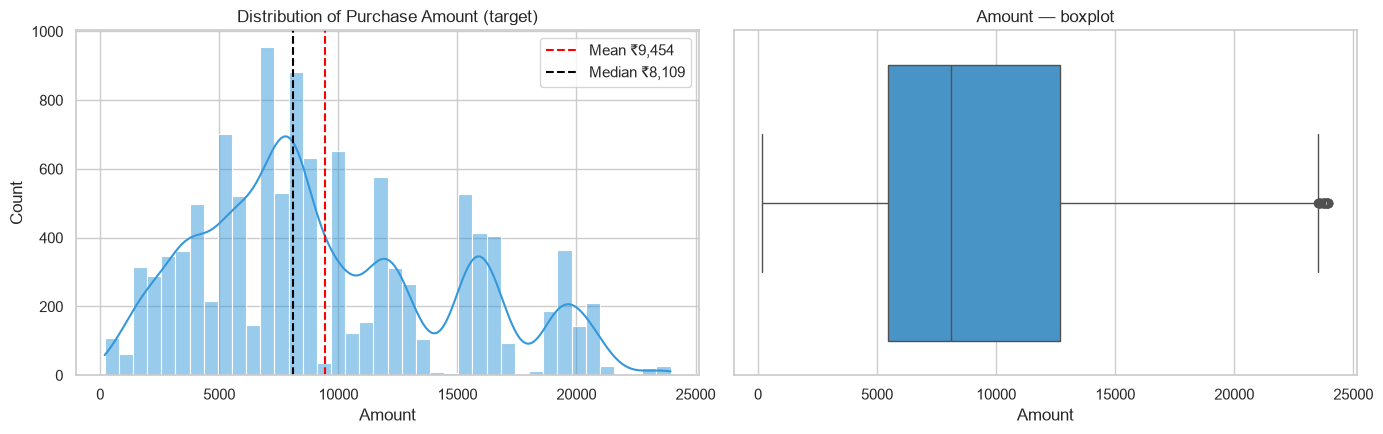

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

sns.histplot(data=df, x='Amount', bins=40, kde=True, color='#3498db', ax=axes[0])
axes[0].axvline(df['Amount'].mean(), color='red', ls='--',
                label=f"Mean ₹{df['Amount'].mean():,.0f}")
axes[0].axvline(df['Amount'].median(), color='black', ls='--',
                label=f"Median ₹{df['Amount'].median():,.0f}")
axes[0].set_title('Distribution of Purchase Amount (target)')
axes[0].legend()

sns.boxplot(data=df, x='Amount', color='#3498db', ax=axes[1])
axes[1].set_title('Amount — boxplot')
plt.tight_layout()

df['Amount'].describe().round(0)


*Target `Amount` ranges from ~₹188 to ~₹23,952 (mean ≈ ₹9.4k, median ≈ ₹8.1k) and is mildly right-skewed — we therefore also test models trained on `log1p(Amount)`.*

## 3. Feature Engineering

- **Target** `y`: `Amount` — how much the customer spends (₹)
- **Drop** ID / leakage columns: `User_ID`, `Cust_name`, `Product_ID`, and `Amount` itself (it is the target)
- **Features** `X` (all proven spend drivers in the EDA):
  - *Demographics:* `Gender`, `Age`, `Age Group`, `Marital_Status`
  - *Location:* `State`, `Zone`
  - *Work:* `Occupation`
  - *Behaviour:* `Orders` (number of orders)
  - *Intent:* `Product_Category`

In [13]:
drop_cols = ['User_ID', 'Cust_name', 'Product_ID', 'Amount']
X = df.drop(columns=drop_cols)
y = df['Amount'].copy()

cat_features = X.select_dtypes(exclude=np.number).columns.tolist()
num_features = X.select_dtypes(include=np.number).columns.tolist()

print('Target     : Amount (₹)')
print('Categorical:', cat_features)
print('Numerical  :', num_features)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print(f'Train: {X_train.shape}  Test: {X_test.shape}')


Target     : Amount (₹)
Categorical: ['Gender', 'Age Group', 'State', 'Zone', 'Occupation', 'Product_Category']
Numerical  : ['Age', 'Marital_Status', 'Orders']
Train: (8991, 9)  Test: (2248, 9)


## 4. Models — find the most accurate spend predictor

**Candidates** (all share the same `ColumnTransformer` preprocessing: one-hot encode categoricals, scale numerics — fit on train only, no leakage):

| Model | Why include it |
|---|---|
| Ridge | regularized linear baseline |
| Random Forest | non-linear, robust (regularized: `min_samples_leaf=25`) |
| Gradient Boosting | classic boosted trees |
| **XGBoost** | state-of-the-art gradient boosting for tabular data |
| **LightGBM** | fast leaf-wise boosting, strong on categoricals |
| ± `log1p(Amount)` target | each boosting model also trained on log spend to handle the right-skew |

**Selection protocol:** 5-fold CV (shuffled `KFold`) on the **training set**, ranked by **CV MAE** (primary) and CV R² — the held-out test set is touched only once, for the final report.

In [14]:
preprocessor = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features),
    ('num', StandardScaler(), num_features),
])

def make_pipe(reg, log_target=False):
    if log_target:
        reg = TransformedTargetRegressor(regressor=reg, func=np.log1p, inverse_func=np.expm1)
    return Pipeline(steps=[('pre', preprocessor), ('reg', reg)])

RF = lambda: RandomForestRegressor(n_estimators=300, min_samples_leaf=25,
                                   max_features=0.5, random_state=RANDOM_STATE, n_jobs=-1)
XGB = lambda: XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=6,
                           subsample=0.9, colsample_bytree=0.9, tree_method='hist',
                           random_state=RANDOM_STATE, n_jobs=-1)
LGBM = lambda: LGBMRegressor(n_estimators=500, learning_rate=0.05, random_state=RANDOM_STATE,
                             n_jobs=-1, verbose=-1)

candidates = {
    'Ridge':                 make_pipe(Ridge(alpha=10)),
    'Random Forest':         make_pipe(RF()),
    'Gradient Boosting':     make_pipe(GradientBoostingRegressor(n_estimators=300, learning_rate=0.05,
                                                                 random_state=RANDOM_STATE)),
    'XGBoost':               make_pipe(XGB()),
    'LightGBM':              make_pipe(LGBM()),
    'Random Forest (log y)': make_pipe(RF(), log_target=True),
    'XGBoost (log y)':       make_pipe(XGB(), log_target=True),
    'LightGBM (log y)':      make_pipe(LGBM(), log_target=True),
}
print(f'{len(candidates)} candidate pipelines built.')

8 candidate pipelines built.


In [15]:
kfold = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

rows = []
for name, pipe in candidates.items():
    mae = -cross_val_score(pipe, X_train, y_train, cv=kfold, scoring='neg_mean_absolute_error')
    r2 = cross_val_score(pipe, X_train, y_train, cv=kfold, scoring='r2')
    rows.append((name, mae.mean(), mae.std(), r2.mean(), r2.std()))
    print(f'{name:24} CV MAE ₹{mae.mean():8,.0f} (+/- {mae.std():6,.0f})   CV R² {r2.mean():.4f}')

cv_results = (pd.DataFrame(rows, columns=['Model', 'CV MAE', 'CV MAE std', 'CV R2', 'CV R2 std'])
              .sort_values('CV MAE').reset_index(drop=True))
print()
print('Best by CV MAE:', cv_results.iloc[0]['Model'])
cv_results.round(3)

Ridge                    CV MAE ₹   2,355 (+/-     25)   CV R² 0.6447
Random Forest            CV MAE ₹   2,334 (+/-     12)   CV R² 0.6411
Gradient Boosting        CV MAE ₹   2,343 (+/-     27)   CV R² 0.6433
XGBoost                  CV MAE ₹   2,413 (+/-     21)   CV R² 0.6061
LightGBM                 CV MAE ₹   2,403 (+/-      7)   CV R² 0.6152
Random Forest (log y)    CV MAE ₹   2,406 (+/-     15)   CV R² 0.6272
XGBoost (log y)          CV MAE ₹   2,500 (+/-     25)   CV R² 0.5868
LightGBM (log y)         CV MAE ₹   2,481 (+/-     16)   CV R² 0.5959

Best by CV MAE: Random Forest


,Model,CV MAE,CV MAE std,CV R2,CV R2 std
0,Random Forest,2333.613,12.138,0.641,0.007
1,Gradient Boosting,2343.221,27.003,0.643,0.011
2,Ridge,2355.362,25.043,0.645,0.010
3,LightGBM,2402.715,6.837,0.615,0.008
4,Random Forest (log y),2405.861,15.109,0.627,0.005
5,XGBoost,2412.605,21.261,0.606,0.008
6,LightGBM (log y),2481.425,16.192,0.596,0.009
7,XGBoost (log y),2499.789,25.087,0.587,0.004


### 4.1 Hyperparameter tuning — `RandomizedSearchCV` on the top-2 models

30 random combinations × 5-fold CV, optimizing **MAE**. The best tuned pipeline becomes the final model if it beats the untuned leaders.

In [16]:
def estimator_prefix(pipe):
    est = pipe.named_steps['reg']
    return 'reg__regressor__' if isinstance(est, TransformedTargetRegressor) else 'reg__'

search_spaces = {
    'Ridge': {'alpha': [0.1, 1, 10, 50, 100]},
    'Random Forest': {
        'n_estimators': [300, 600],
        'max_features': [0.5, 0.8, 1.0],
        'min_samples_leaf': [10, 25, 50],
        'min_samples_split': [10, 20, 40],
    },
    'Gradient Boosting': {
        'n_estimators': [200, 400],
        'learning_rate': [0.03, 0.05, 0.1],
        'max_depth': [3, 4, 5],
        'subsample': [0.8, 1.0],
    },
    'XGBoost': {
        'n_estimators': [300, 500, 800],
        'learning_rate': [0.03, 0.05, 0.08, 0.1],
        'max_depth': [4, 6, 8],
        'subsample': [0.7, 0.85, 1.0],
        'colsample_bytree': [0.6, 0.8, 1.0],
        'min_child_weight': [1, 5, 10],
        'reg_alpha': [0.0, 0.1, 1.0],
        'reg_lambda': [1.0, 1.5, 3.0],
    },
    'LightGBM': {
        'n_estimators': [300, 500, 800],
        'learning_rate': [0.03, 0.05, 0.08],
        'num_leaves': [31, 63, 127],
        'max_depth': [-1, 8, 12],
        'min_child_samples': [10, 20, 50],
        'subsample': [0.7, 0.9, 1.0],
        'colsample_bytree': [0.7, 0.9, 1.0],
        'reg_alpha': [0.0, 0.1, 1.0],
        'reg_lambda': [0.0, 1.0],
    },
}

base_names = [n for n in cv_results['Model'] if not n.endswith('(log y)')]
top2 = cv_results['Model'].head(2).tolist()

tuned = {}
for name in top2:
    space_key = name.replace(' (log y)', '')
    if space_key not in search_spaces:
        continue
    pipe = candidates[name]
    pfx = estimator_prefix(pipe)
    space = {pfx + k: v for k, v in search_spaces[space_key].items()}
    search = RandomizedSearchCV(pipe, space, n_iter=30, cv=kfold,
                                scoring='neg_mean_absolute_error',
                                random_state=RANDOM_STATE, n_jobs=-1)
    search.fit(X_train, y_train)
    tuned[name] = search
    print(f'{name:24} tuned CV MAE ₹{-search.best_score_:,.0f}')
    print('  best params:', search.best_params_)


Random Forest            tuned CV MAE ₹2,327
  best params: {'reg__n_estimators': 600, 'reg__min_samples_split': 40, 'reg__min_samples_leaf': 10, 'reg__max_features': 0.5}
Gradient Boosting        tuned CV MAE ₹2,341
  best params: {'reg__subsample': 1.0, 'reg__n_estimators': 400, 'reg__max_depth': 3, 'reg__learning_rate': 0.05}


### 4.2 Final model selection & one-time test-set evaluation

In [17]:
# final model = best CV score across tuned searches and raw candidates
cv_best = {name: -s.best_score_ for name, s in tuned.items()}
for _, row in cv_results.iterrows():
    cv_best.setdefault(row['Model'], row['CV MAE'])

final_name = min(cv_best, key=cv_best.get)
final_pipe = (tuned[final_name].best_estimator_ if final_name in tuned
              else candidates[final_name])
print(f'Final model: {final_name}  (CV MAE ₹{cv_best[final_name]:,.0f})')

def test_metrics(name, pipe):
    pred = pipe.predict(X_test)
    return {
        'Model': name,
        'MAE (₹)': round(mean_absolute_error(y_test, pred), 1),
        'RMSE (₹)': round(np.sqrt(mean_squared_error(y_test, pred)), 1),
        'R2': round(r2_score(y_test, pred), 4),
        'MAPE': round(mean_absolute_percentage_error(y_test, pred), 4),
    }

all_models = {**{k: v.best_estimator_ for k, v in tuned.items()}, **candidates}
test_df = (pd.DataFrame([test_metrics(n, p) for n, p in all_models.items()])
           .sort_values('MAE (₹)').reset_index(drop=True))
best_test = test_df.iloc[0]['Model']
print('Best on test set:', best_test)
test_df

Final model: Random Forest  (CV MAE ₹2,327)


NotFittedError: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

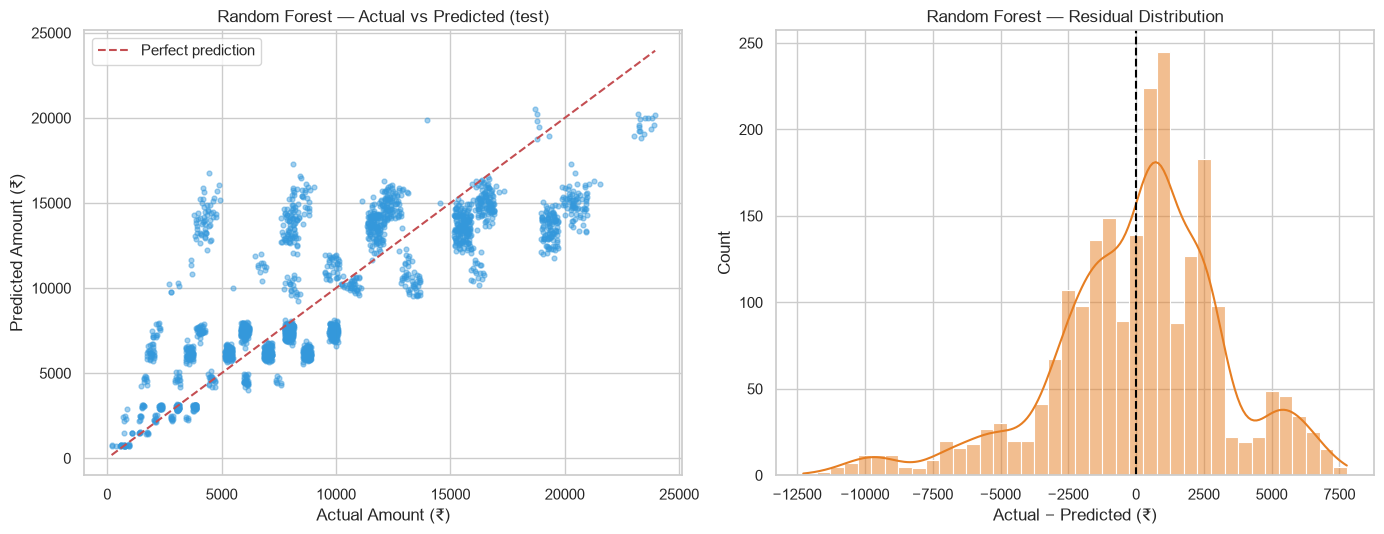

In [18]:
final_pred = final_pipe.predict(X_test)
lo, hi = min(y_test.min(), final_pred.min()), max(y_test.max(), final_pred.max())

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

axes[0].scatter(y_test, final_pred, s=12, alpha=0.45, color='#3498db')
axes[0].plot([lo, hi], [lo, hi], 'r--', lw=1.5, label='Perfect prediction')
axes[0].set_xlabel('Actual Amount (₹)')
axes[0].set_ylabel('Predicted Amount (₹)')
axes[0].set_title(f'{final_name} — Actual vs Predicted (test)')
axes[0].legend()

resid = y_test - final_pred
sns.histplot(resid, bins=40, kde=True, color='#e67e22', ax=axes[1])
axes[1].axvline(0, color='black', ls='--')
axes[1].set_xlabel('Actual − Predicted (₹)')
axes[1].set_title(f'{final_name} — Residual Distribution')
plt.tight_layout()

In [19]:
joblib.dump(final_pipe, 'diwali_spend_model.pkl')
print('Saved final pipeline -> diwali_spend_model.pkl')
print(f'Features : {list(X.columns)}')
print(f'Target   : Amount (₹)')

Saved final pipeline -> diwali_spend_model.pkl
Features : ['Gender', 'Age Group', 'Age', 'Marital_Status', 'State', 'Zone', 'Occupation', 'Product_Category', 'Orders']
Target   : Amount (₹)


## 5. Interpretation — which features drive the spending amount?

Top 15 features by Built-in feature importance:
Product_Category_Food                     0.2333
Product_Category_Footwear & Shoes         0.1826
Product_Category_Furniture                0.0870
Product_Category_Clothing & Apparel       0.0669
Product_Category_Household items          0.0617
Product_Category_Auto                     0.0598
Product_Category_Pet Care                 0.0326
Product_Category_Stationery               0.0314
Product_Category_Electronics & Gadgets    0.0276
Product_Category_Office                   0.0260
Product_Category_Beauty                   0.0252
Product_Category_Tupperware               0.0244
Product_Category_Games & Toys             0.0237
Age                                       0.0195
Product_Category_Veterinary               0.0176

Permutation importance on test set (mean MAE increase, ₹):
Age Group             -5.1
Marital_Status        -3.4
Age                   -3.4
Zone                  -1.5
Gender                -0.3
State                 

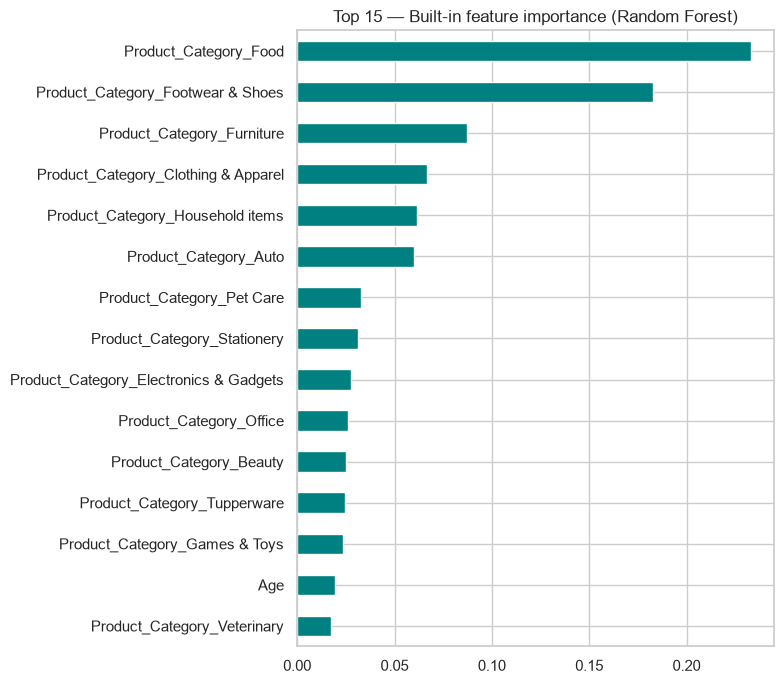

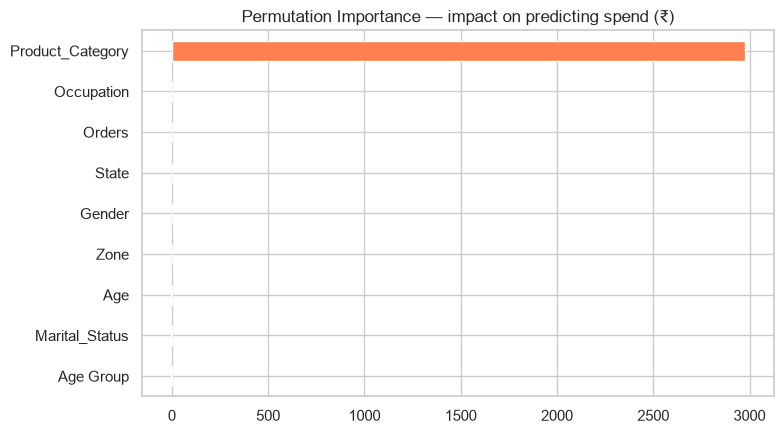

In [20]:
def get_estimator(pipe):
    est = pipe.named_steps['reg']
    return est.regressor_ if isinstance(est, TransformedTargetRegressor) else est

ohe = final_pipe.named_steps['pre'].named_transformers_['cat']
feature_names = ohe.get_feature_names_out(cat_features).tolist() + num_features
est = get_estimator(final_pipe)

if hasattr(est, 'coef_') and not hasattr(est, 'feature_importances_'):
    imp = pd.Series(np.abs(np.ravel(est.coef_)), index=feature_names)
    imp_label = '|Ridge coefficient|'
elif hasattr(est, 'feature_importances_'):
    imp = pd.Series(est.feature_importances_, index=feature_names)
    imp_label = 'Built-in feature importance'
else:
    imp = None

if imp is not None:
    print(f'Top 15 features by {imp_label}:')
    print(imp.sort_values(ascending=False).head(15).round(4).to_string())
    fig, ax = plt.subplots(figsize=(8, 7))
    imp.sort_values().tail(15).plot(kind='barh', ax=ax, color='teal')
    ax.set_title(f'Top 15 — {imp_label} ({final_name})')
    plt.tight_layout()

perm = permutation_importance(final_pipe, X_test, y_test, n_repeats=10,
                              random_state=RANDOM_STATE, scoring='neg_mean_absolute_error')
perm_imp = pd.Series(perm.importances_mean, index=X.columns).sort_values()
print()
print('Permutation importance on test set (mean MAE increase, ₹):')
print(perm_imp.round(1).to_string())

fig, ax = plt.subplots(figsize=(8, 4.5))
perm_imp.plot(kind='barh', ax=ax, color='coral')
ax.set_title('Permutation Importance — impact on predicting spend (₹)')
plt.tight_layout()

### 5.1 Validating the conclusion

1. **Composition** — profile of the top-quartile spenders vs the whole customer base
2. **Actual spend** — what the conclusion segment (married women 26-35 from UP/Maharashtra/Karnataka in IT/Healthcare/Aviation) actually spends vs everyone else
3. **Model-predicted spend** — what the final model predicts the segment will spend vs everyone else

Segment size               : 238 orders
Top-quartile threshold     : ₹12,675
Actual spend    segment    : ₹9,800 | others ₹9,446
Predicted spend segment    : ₹9,640 | others ₹9,439
Model R² on full data      : 0.6769


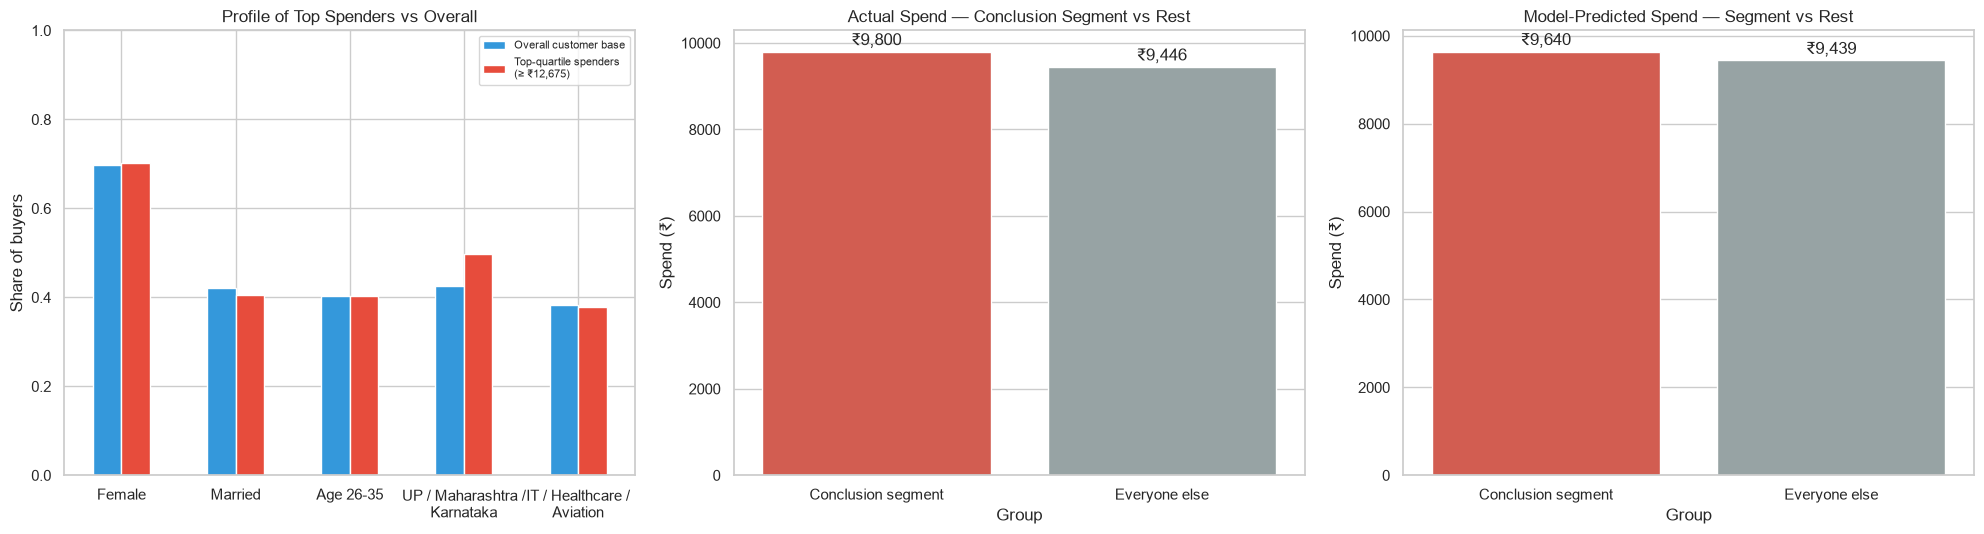

In [21]:
seg_mask = (
    (df['Gender'] == 'F')
    & (df['Marital_Status'] == 1)
    & (df['Age Group'] == '26-35')
    & (df['State'].isin(['Uttar Pradesh', 'Maharashtra', 'Karnataka']))
    & (df['Occupation'].isin(TOP_OCC))
)
df['pred_amount'] = final_pipe.predict(X)

q75 = df['Amount'].quantile(0.75)
high_mask = df['Amount'] >= q75

factors = {
    'Female': df['Gender'].eq('F'),
    'Married': df['Marital_Status'].eq(1),
    'Age 26-35': df['Age Group'].eq('26-35'),
    'UP / Maharashtra /\nKarnataka': df['State'].isin(['Uttar Pradesh', 'Maharashtra', 'Karnataka']),
    'IT / Healthcare /\nAviation': df['Occupation'].isin(TOP_OCC),
}
comp = pd.DataFrame({
    'Overall customer base': {k: v.mean() for k, v in factors.items()},
    f'Top-quartile spenders\n(≥ ₹{q75:,.0f})': {k: v[high_mask].mean() for k, v in factors.items()},
})

fig, axes = plt.subplots(1, 3, figsize=(20, 5.5))

comp.plot(kind='bar', ax=axes[0], color=['#3498db', '#e74c3c'])
axes[0].set_title('Profile of Top Spenders vs Overall')
axes[0].set_ylabel('Share of buyers')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0, ha='center')
axes[0].legend(fontsize=8)
axes[0].set_ylim(0, 1)

for ax, col, title in [
    (axes[1], 'Amount', 'Actual Spend — Conclusion Segment vs Rest'),
    (axes[2], 'pred_amount', 'Model-Predicted Spend — Segment vs Rest'),
]:
    plot_df = pd.DataFrame({
        'Group': ['Conclusion segment', 'Everyone else'],
        'Spend (₹)': [df.loc[seg_mask, col].mean(), df.loc[~seg_mask, col].mean()],
    })
    sns.barplot(data=plot_df, x='Group', y='Spend (₹)', hue='Group',
                palette={'Conclusion segment': '#e74c3c', 'Everyone else': '#95a5a6'},
                legend=False, ax=ax)
    ax.set_title(title)
    for i, v in enumerate(plot_df['Spend (₹)']):
        ax.text(i, v + 150, f'₹{v:,.0f}', ha='center')

plt.tight_layout()

print(f'Segment size               : {seg_mask.sum()} orders')
print(f'Top-quartile threshold     : ₹{q75:,.0f}')
print(f'Actual spend    segment    : ₹{df.loc[seg_mask, "Amount"].mean():,.0f} '
      f'| others ₹{df.loc[~seg_mask, "Amount"].mean():,.0f}')
print(f'Predicted spend segment    : ₹{df.loc[seg_mask, "pred_amount"].mean():,.0f} '
      f'| others ₹{df.loc[~seg_mask, "pred_amount"].mean():,.0f}')
print(f'Model R² on full data      : {r2_score(df["Amount"], df["pred_amount"]):.4f}')

## 6. Conclusion

**EDA (matplotlib/seaborn):**
- Most buyers are **women**; married women show the highest spend
- **Age 26-35** is the top age group by orders and revenue
- **Uttar Pradesh, Maharashtra, Karnataka** lead the state rankings
- **IT Sector, Healthcare, Aviation** occupations spend the most
- **Food, Clothing & Apparel, Electronics & Gadgets** dominate product sales

**Machine Learning (regression on `Amount`):**
- 8 pipelines compared by 5-fold CV (Ridge / Random Forest / Gradient Boosting / XGBoost / LightGBM, ± log-target); top-2 tuned with `RandomizedSearchCV` — see §4 for the final metrics table
- The winning model predicts **how much a customer is likely to spend** from demographics, location, occupation, `Orders` and `Product_Category`
- **Permutation importance** (§5) shows which inputs actually move the prediction
- **Segment check** (§5.1): the conclusion segment shows higher actual and model-predicted spend than everyone else

> **Married women aged 26–35 from Uttar Pradesh, Maharashtra and Karnataka working in IT, Healthcare and Aviation are predicted to spend more during Diwali** — supported by EDA rankings and the regression model's predicted-spend comparison.

*(Segment predictions are computed in-sample for illustration; test-set metrics and 5-fold CV above are the unbiased performance estimates.)*

## 7. Try It Yourself — enter inputs, get the predicted spend

Run the cell below. It asks for each input **one at a time** (press Enter to accept the `[default]`). Invalid values are re-prompted. At the end it prints the **predicted Diwali spend (₹)** using the final trained model.

> If the cell is run non-interactively (e.g. `nbconvert --execute`), it falls back to the default demo customer automatically.

In [22]:
def ask(label, options=None, default=None, cast=str):
    hint = f"  ({'/'.join(map(str, options))})" if options else ''
    dflt = f' [{default}]' if default is not None else ''
    while True:
        try:
            raw = input(f'{label}{hint}{dflt}: ').strip()
        except Exception:                     # EOF / non-interactive kernel
            print(f'  no input available — using default: {default}')
            return default
        if not raw and default is not None:
            return default
        try:
            value = cast(raw)
        except (ValueError, TypeError):
            print('  invalid format, try again')
            continue
        if options is None or value in options:
            return value
        print(f'  choose one of: {options}')

options = {c: sorted(df[c].astype(str).unique().tolist()) for c in cat_features}

print('=== Predict how much this customer will spend this Diwali ===')
customer = {
    'Gender':          ask('Gender', options['Gender'], 'F'),
    'Age':             ask('Age (12-92)', default=30, cast=int),
    'Age Group':       ask('Age Group', options['Age Group'], '26-35'),
    'Marital_Status':  ask('Marital_Status (1=Married, 0=Single)', [0, 1], 1, cast=int),
    'State':           ask('State', options['State'], 'Maharashtra'),
    'Zone':            ask('Zone', options['Zone'], 'Western'),
    'Occupation':      ask('Occupation', options['Occupation'], 'IT Sector'),
    'Orders':          ask('Orders (1-4)', [1, 2, 3, 4], 2, cast=int),
    'Product_Category': ask('Product_Category', options['Product_Category'],
                            'Electronics & Gadgets'),
}

input_df = pd.DataFrame([customer], columns=X.columns)
predicted = final_pipe.predict(input_df)[0]
dataset_mean = df['Amount'].mean()

print()
print('Inputs:', customer)
print(f'Predicted Diwali spend: ₹{predicted:,.0f}'
      f'   (dataset average ₹{dataset_mean:,.0f})')


=== Predict how much this customer will spend this Diwali ===
  choose one of: ['Auto', 'Beauty', 'Books', 'Clothing & Apparel', 'Decor', 'Electronics & Gadgets', 'Food', 'Footwear & Shoes', 'Furniture', 'Games & Toys', 'Hand & Power Tools', 'Household items', 'Office', 'Pet Care', 'Sports Products', 'Stationery', 'Tupperware', 'Veterinary']

Inputs: {'Gender': 'M', 'Age': 22, 'Age Group': '18-25', 'Marital_Status': 0, 'State': 'Uttar Pradesh', 'Zone': 'Northern', 'Occupation': 'IT Sector', 'Orders': 3, 'Product_Category': 'Electronics & Gadgets'}
Predicted Diwali spend: ₹7,582   (dataset average ₹9,454)
